In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Load CSV
df = pd.read_csv("Invistico_Airline.csv")

# Inspect target variable
df['satisfaction'].value_counts()

,count
satisfaction,
dissatisfied,26706
satisfied,19593


In [2]:
# Encode categorical predictors
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,0,65,1,1,265,0,0,0,2,...,2,3,3,0,3,5.0,3.0,2.0,0.0,0.0
1,1,0,47,1,0,2464,0,0,0,3,...,2,3,4,4,4,2.0,3.0,2.0,310.0,305.0
2,1,0,15,1,1,2138,0,0,0,3,...,2,2,3,3,4,4.0,4.0,2.0,0.0,0.0
3,1,0,60,1,1,623,0,0,0,3,...,3,1,1,0,1,4.0,1.0,3.0,0.0,0.0
4,1,0,70,1,1,354,0,0,0,3,...,4,2,2,0,2,4.0,2.0,5.0,0.0,0.0


In [8]:
df_encoded_cleaned = df_encoded.fillna(df_encoded.mean(numeric_only=True))

X = df_encoded_cleaned.drop(columns=["satisfaction"])
y = df_encoded_cleaned["satisfaction"]

# Identify columns with zero standard deviation and drop them
# This prevents StandardScaler from producing NaNs/Infs due to division by zero
zero_std_cols = X.columns[X.std() == 0]
if not zero_std_cols.empty:
    print(f"Dropping columns with zero standard deviation: {list(zero_std_cols)}")
    X = X.drop(columns=zero_std_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

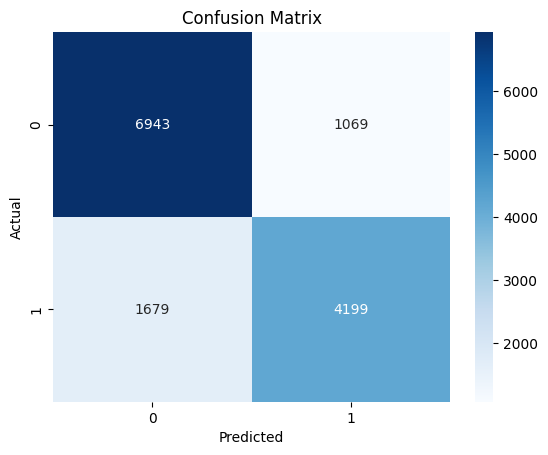

              precision    recall  f1-score   support

           0       0.81      0.87      0.83      8012
           1       0.80      0.71      0.75      5878

    accuracy                           0.80     13890
   macro avg       0.80      0.79      0.79     13890
weighted avg       0.80      0.80      0.80     13890



In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precision, Recall, F1
print(classification_report(y_test, y_pred))

In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient
10,Inflight entertainment,1.045443
12,Ease of Online booking,0.516224
5,Seat comfort,0.485880
14,Leg room service,0.266281
13,On-board service,0.238418
11,Online support,0.221211
2,Type of Travel,0.169990
8,Gate location,0.143836
16,Checkin service,0.124256
15,Baggage handling,-0.002136
